# New-Gen Local Window Analysis

Compare global layer scores against local-window anomaly scores across detector families.

In [ ]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams.update({'figure.figsize': (16, 5), 'axes.grid': True, 'grid.alpha': 0.3})

ROOT = Path.cwd().resolve()
for p in [ROOT, *ROOT.parents]:
    if (p / 'notebooks' / 'new-gen' / '_newgen_utils.py').exists():
        ROOT = p
        break

sys.path.insert(0, str(ROOT / 'notebooks' / 'new-gen'))
from _newgen_utils import latest_structural_runs, select_run_files, load_json, safe_layer_map, sorted_layers_from_map, get_model_name, iter_valid_tests, get_target_layer

In [ ]:
model_filter = ['gpt2-large', 'gpt2-xl', 'qwen3-4b']
use_sweep_aware = True

selection = 'latest_model_sweep' if use_sweep_aware else 'latest_model'
all_run_files = latest_structural_runs(
    ROOT,
    max_files=500,
    model_substrings=model_filter,
    include_outputs=True,
    recursive=True,
)
run_files = select_run_files(all_run_files, selection=selection)
payloads = [load_json(p) for p in run_files]
print(f'Loaded {len(payloads)} run files (selection={selection})')
for p in run_files:
    print(' -', p.name)

Loaded 9 run files
 - rome_structural_qwen3-4b_tk64_tf3_tl3_nl2_rw9_lw5-9-13_s02_r01_2026-03-24_14-23-43.json
 - rome_structural_qwen3-4b_tk50_tf2_tl2_nl1_rw5_lw3-5-7_s01_r01_2026-03-24_14-07-42.json
 - rome_structural_gpt2-xl_tk64_tf3_tl3_nl2_rw9_lw5-9-13_s02_r01_2026-03-24_13-57-39.json
 - rome_structural_gpt2-xl_tk50_tf2_tl2_nl1_rw5_lw3-5-7_s01_r01_2026-03-24_13-47-38.json
 - rome_structural_gpt2-large_tk64_tf3_tl3_nl2_rw9_lw5-9-13_s02_r01_2026-03-24_13-42-54.json
 - rome_structural_gpt2-large_tk50_tf2_tl2_nl1_rw5_lw3-5-7_s01_r01_2026-03-24_13-38-10.json
 - rome_structural_gpt2-xl_2026-03-24_02-47-55.json
 - rome_structural_gpt2-large_2026-03-24_01-20-36.json
 - rome_structural_qwen3-4b_2026-03-23_18-09-51.json


In [3]:
def collect_raw_vs_local(payload, family, raw_key, local_series, local_key='max_local_rank'):
    rows = []
    model = get_model_name(payload)
    for case in iter_valid_tests(payload):
        block = case.get(f'{family}_detection', {})
        raw_map = block.get(raw_key, {})
        local_map = block.get('local_window_scores', {}).get(local_series, {}).get(local_key, {})
        if not isinstance(raw_map, dict) or not isinstance(local_map, dict):
            continue
        layers = sorted(set(sorted_layers_from_map(raw_map)) | set(sorted_layers_from_map(local_map)))
        tgt = get_target_layer(payload, case)
        for layer in layers:
            rows.append({
                'model': model,
                'family': family,
                'case_id': case.get('case_id', -1),
                'layer': layer,
                'raw_score': float(safe_layer_map(raw_map, layer, np.nan)),
                'local_score': float(safe_layer_map(local_map, layer, np.nan)),
                'target_layer': tgt if tgt is not None else np.nan,
            })
    return pd.DataFrame(rows)

family_specs = [
    ('spectral', 'rome_hybrid_scores', 'rome_hybrid_scores'),
    ('attention', 'combined_score', 'raw_rank'),
    ('rank1_blind', 'combined_score', 'raw_rank'),
    ('symmetry', 'combined_score', 'raw_rank'),
]

frames = []
for payload in payloads:
    for family, raw_key, local_series in family_specs:
        df = collect_raw_vs_local(payload, family, raw_key, local_series)
        if not df.empty:
            frames.append(df)

local_df = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
local_df.head()

,model,family,case_id,layer,raw_score,local_score,target_layer
0,Qwen/Qwen3-4B,spectral,0,0,0.000000,0.000000,12
1,Qwen/Qwen3-4B,spectral,0,1,0.000000,0.000000,12
2,Qwen/Qwen3-4B,spectral,0,2,0.000000,0.000000,12
3,Qwen/Qwen3-4B,spectral,0,3,0.476986,0.482759,12
4,Qwen/Qwen3-4B,spectral,0,4,0.397978,0.793103,12


In [4]:
if local_df.empty:
    print('No local-window data available in selected runs.')
else:
    summary = (local_df
               .groupby(['model', 'family'])[['raw_score', 'local_score']]
               .mean()
               .reset_index())
    display(summary)

,model,family,raw_score,local_score
0,Qwen/Qwen3-4B,attention,0.620988,0.669180
1,Qwen/Qwen3-4B,rank1_blind,0.606591,0.683201
2,Qwen/Qwen3-4B,spectral,0.539130,0.594256
3,Qwen/Qwen3-4B,symmetry,0.609253,0.649206
4,gpt2-large,attention,0.615097,0.696825
5,gpt2-large,rank1_blind,0.602527,0.675794
6,gpt2-large,spectral,0.533785,0.587906
7,gpt2-large,symmetry,0.607321,0.668386
8,gpt2-xl,attention,0.618962,0.708407
9,gpt2-xl,rank1_blind,0.602434,0.677453


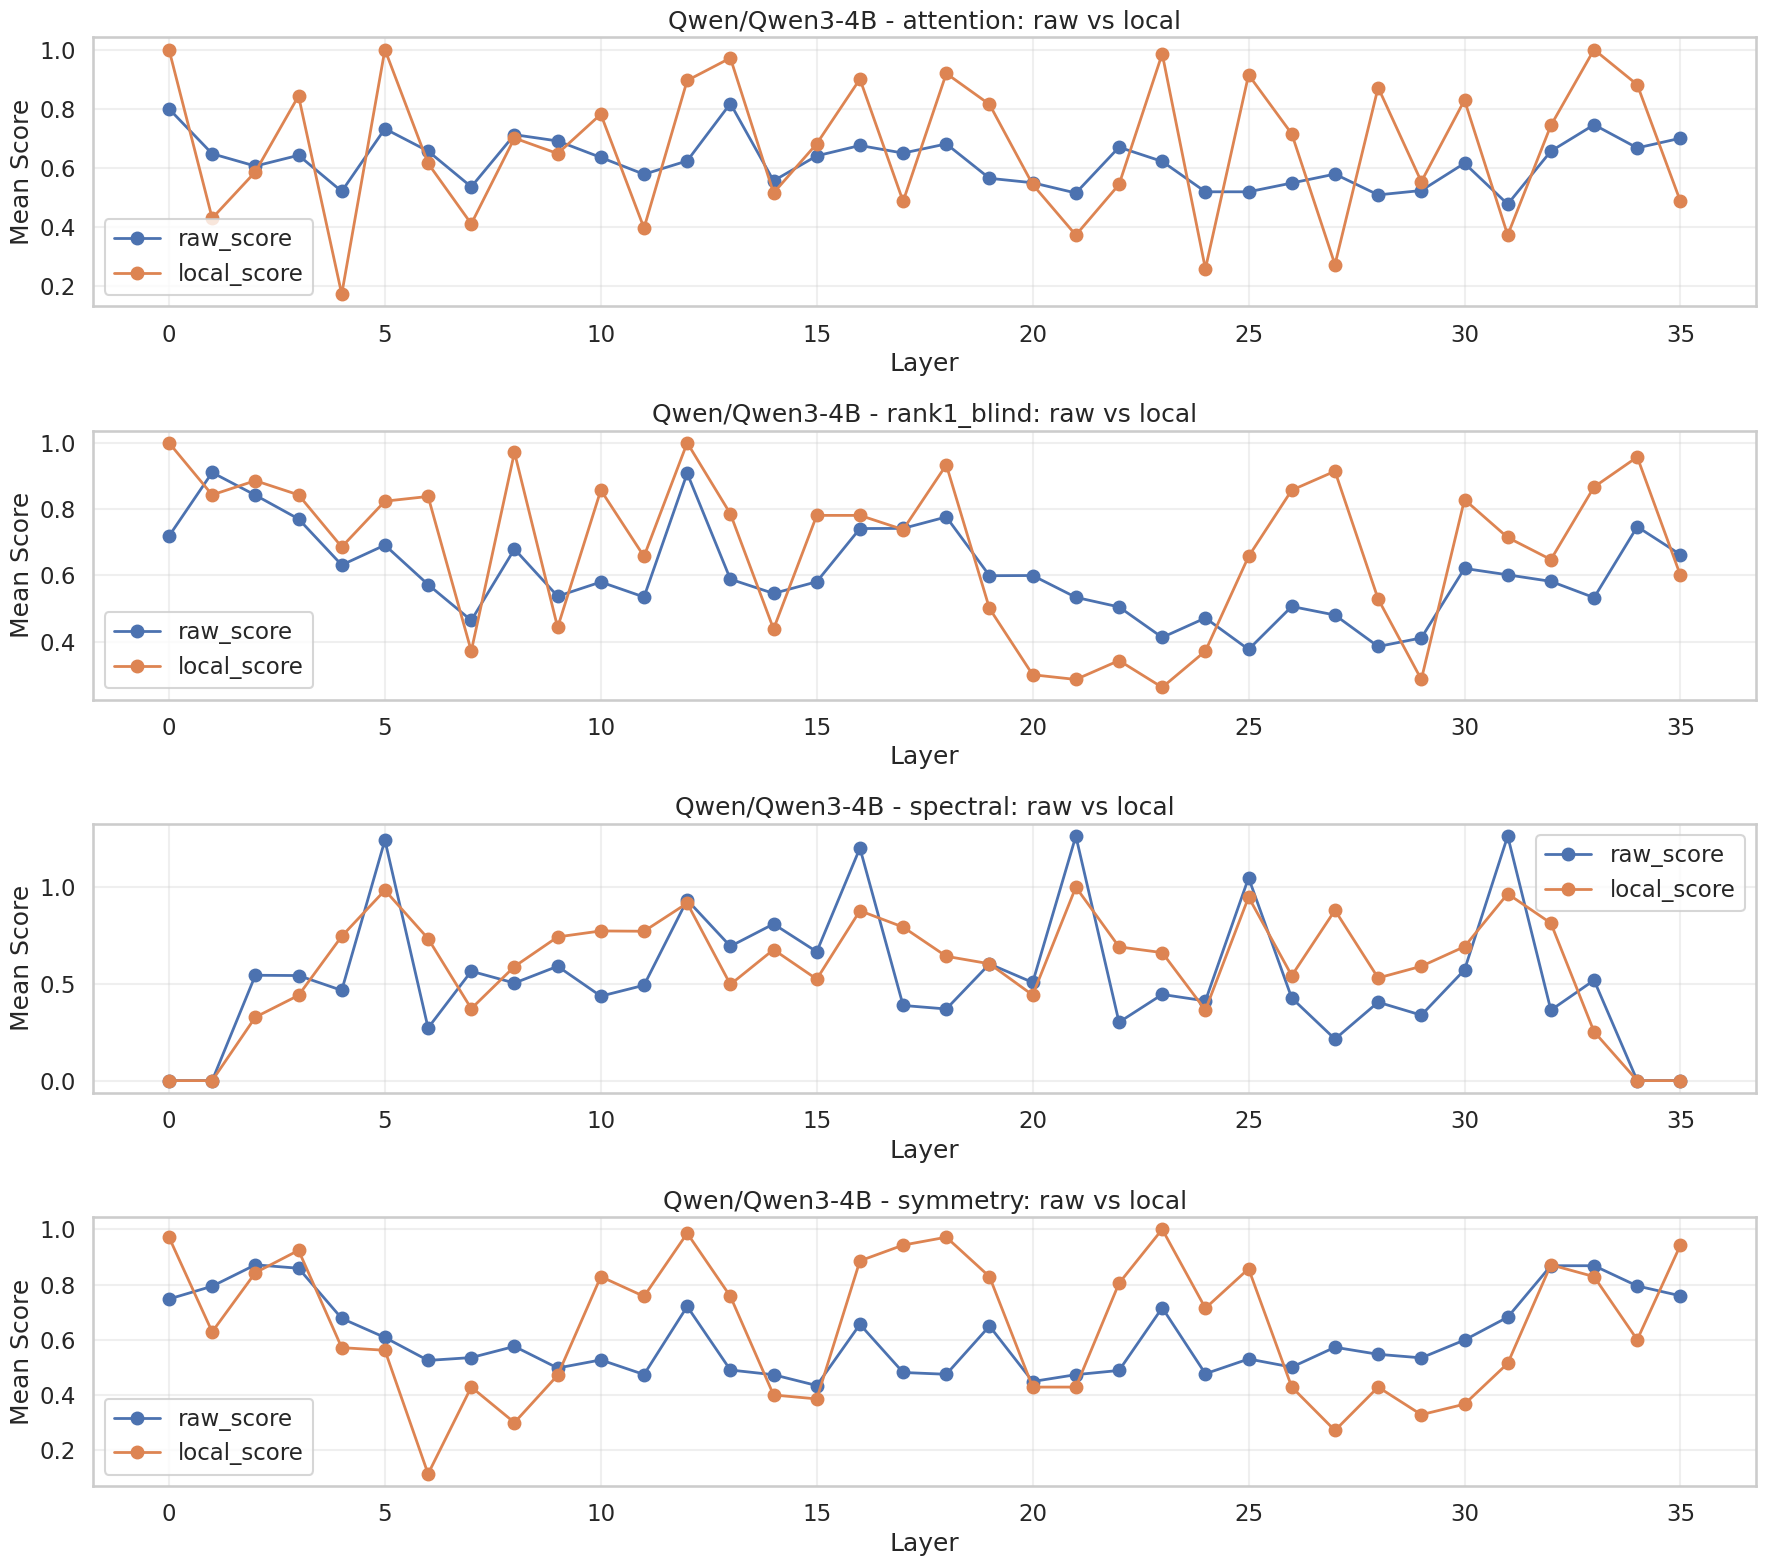

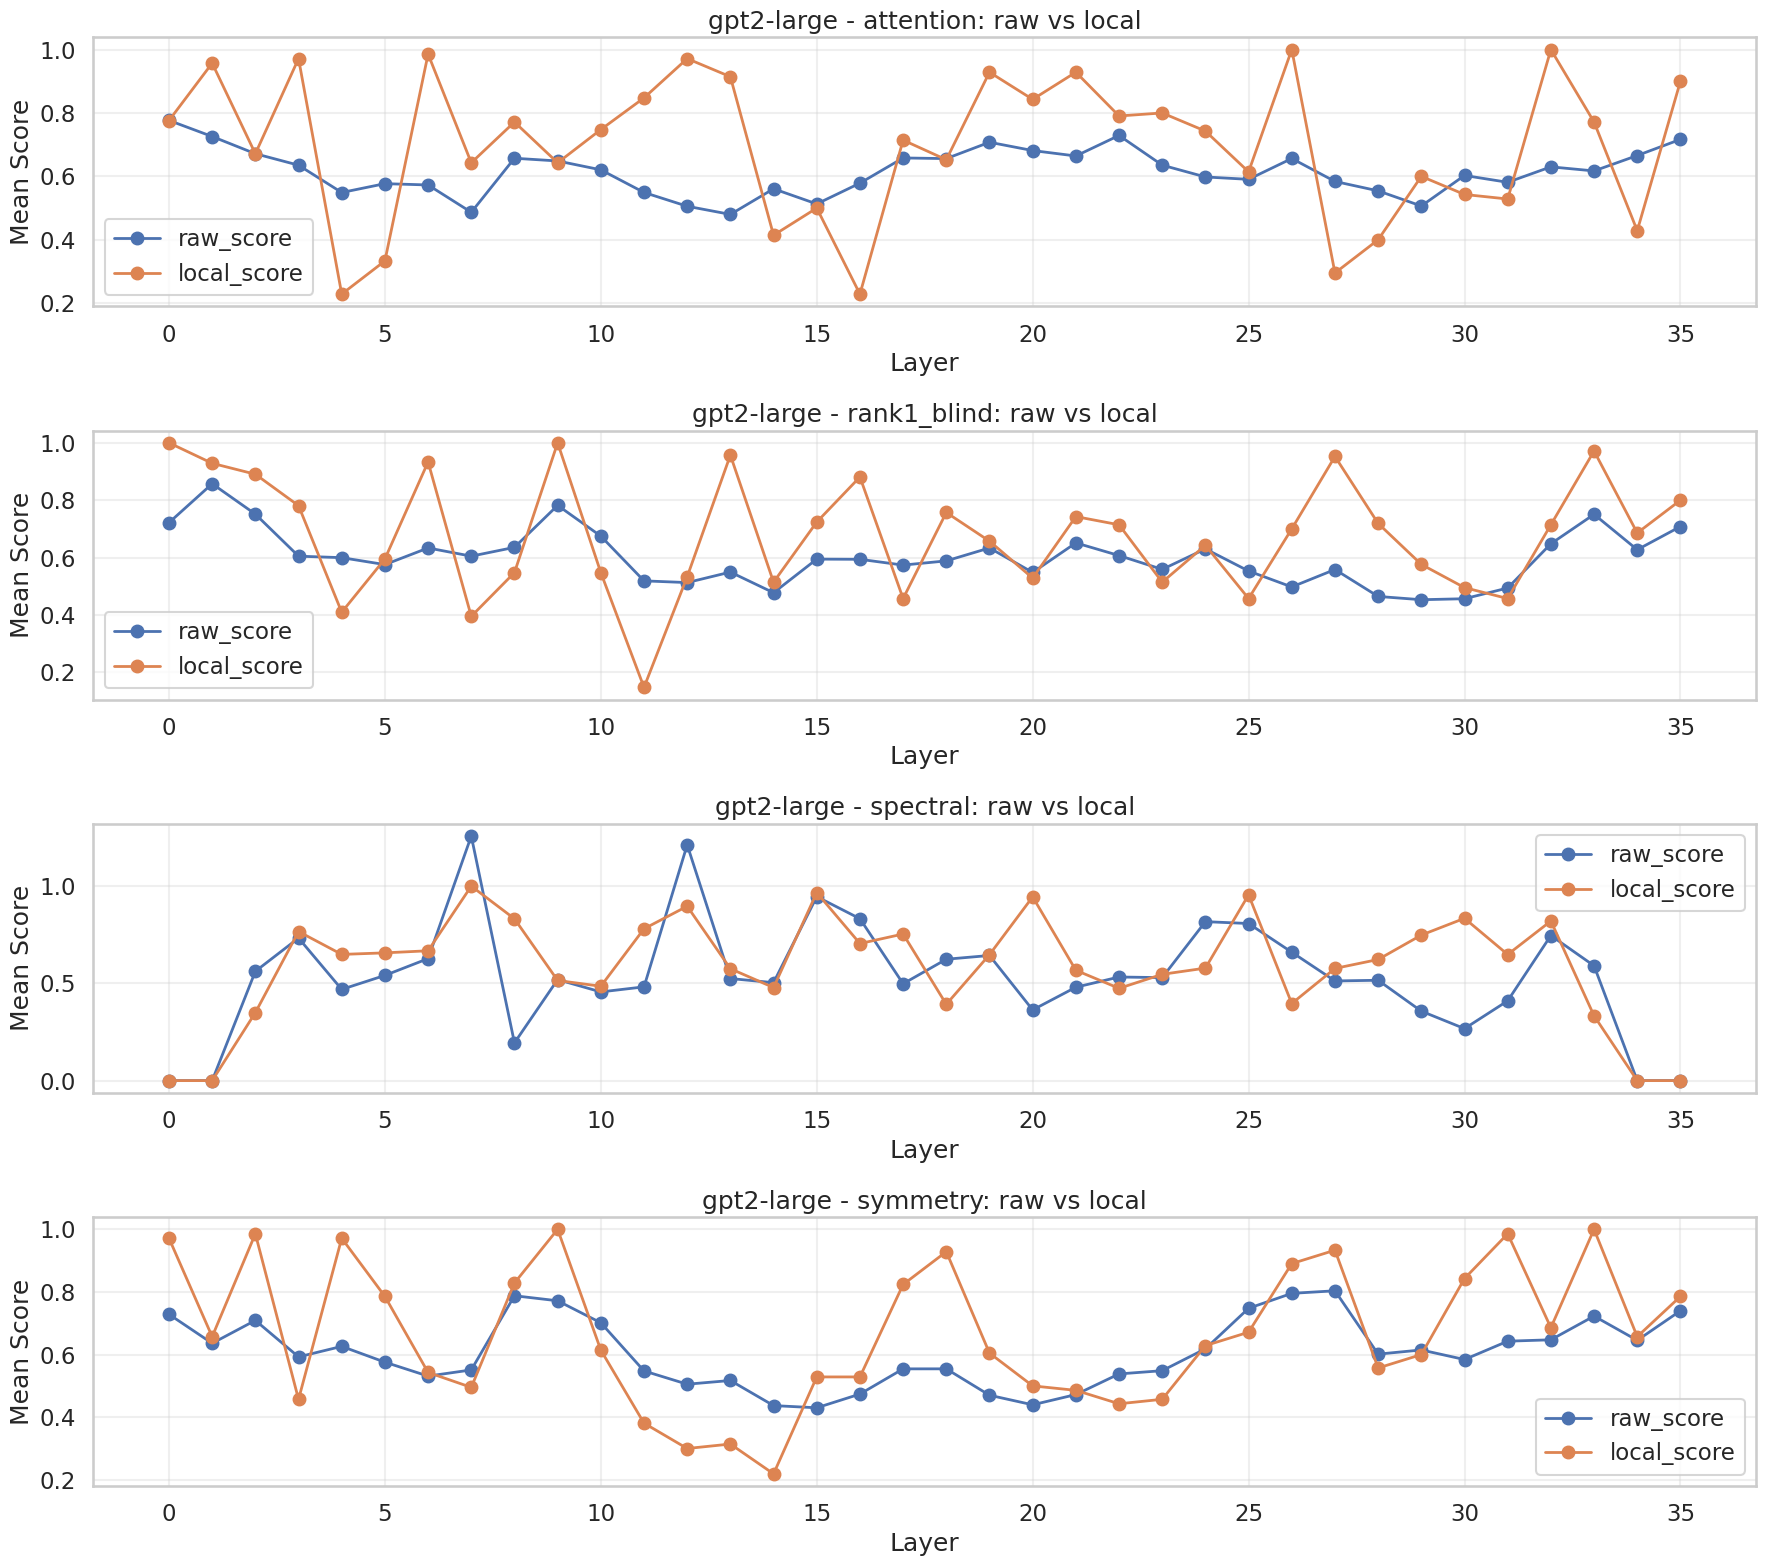

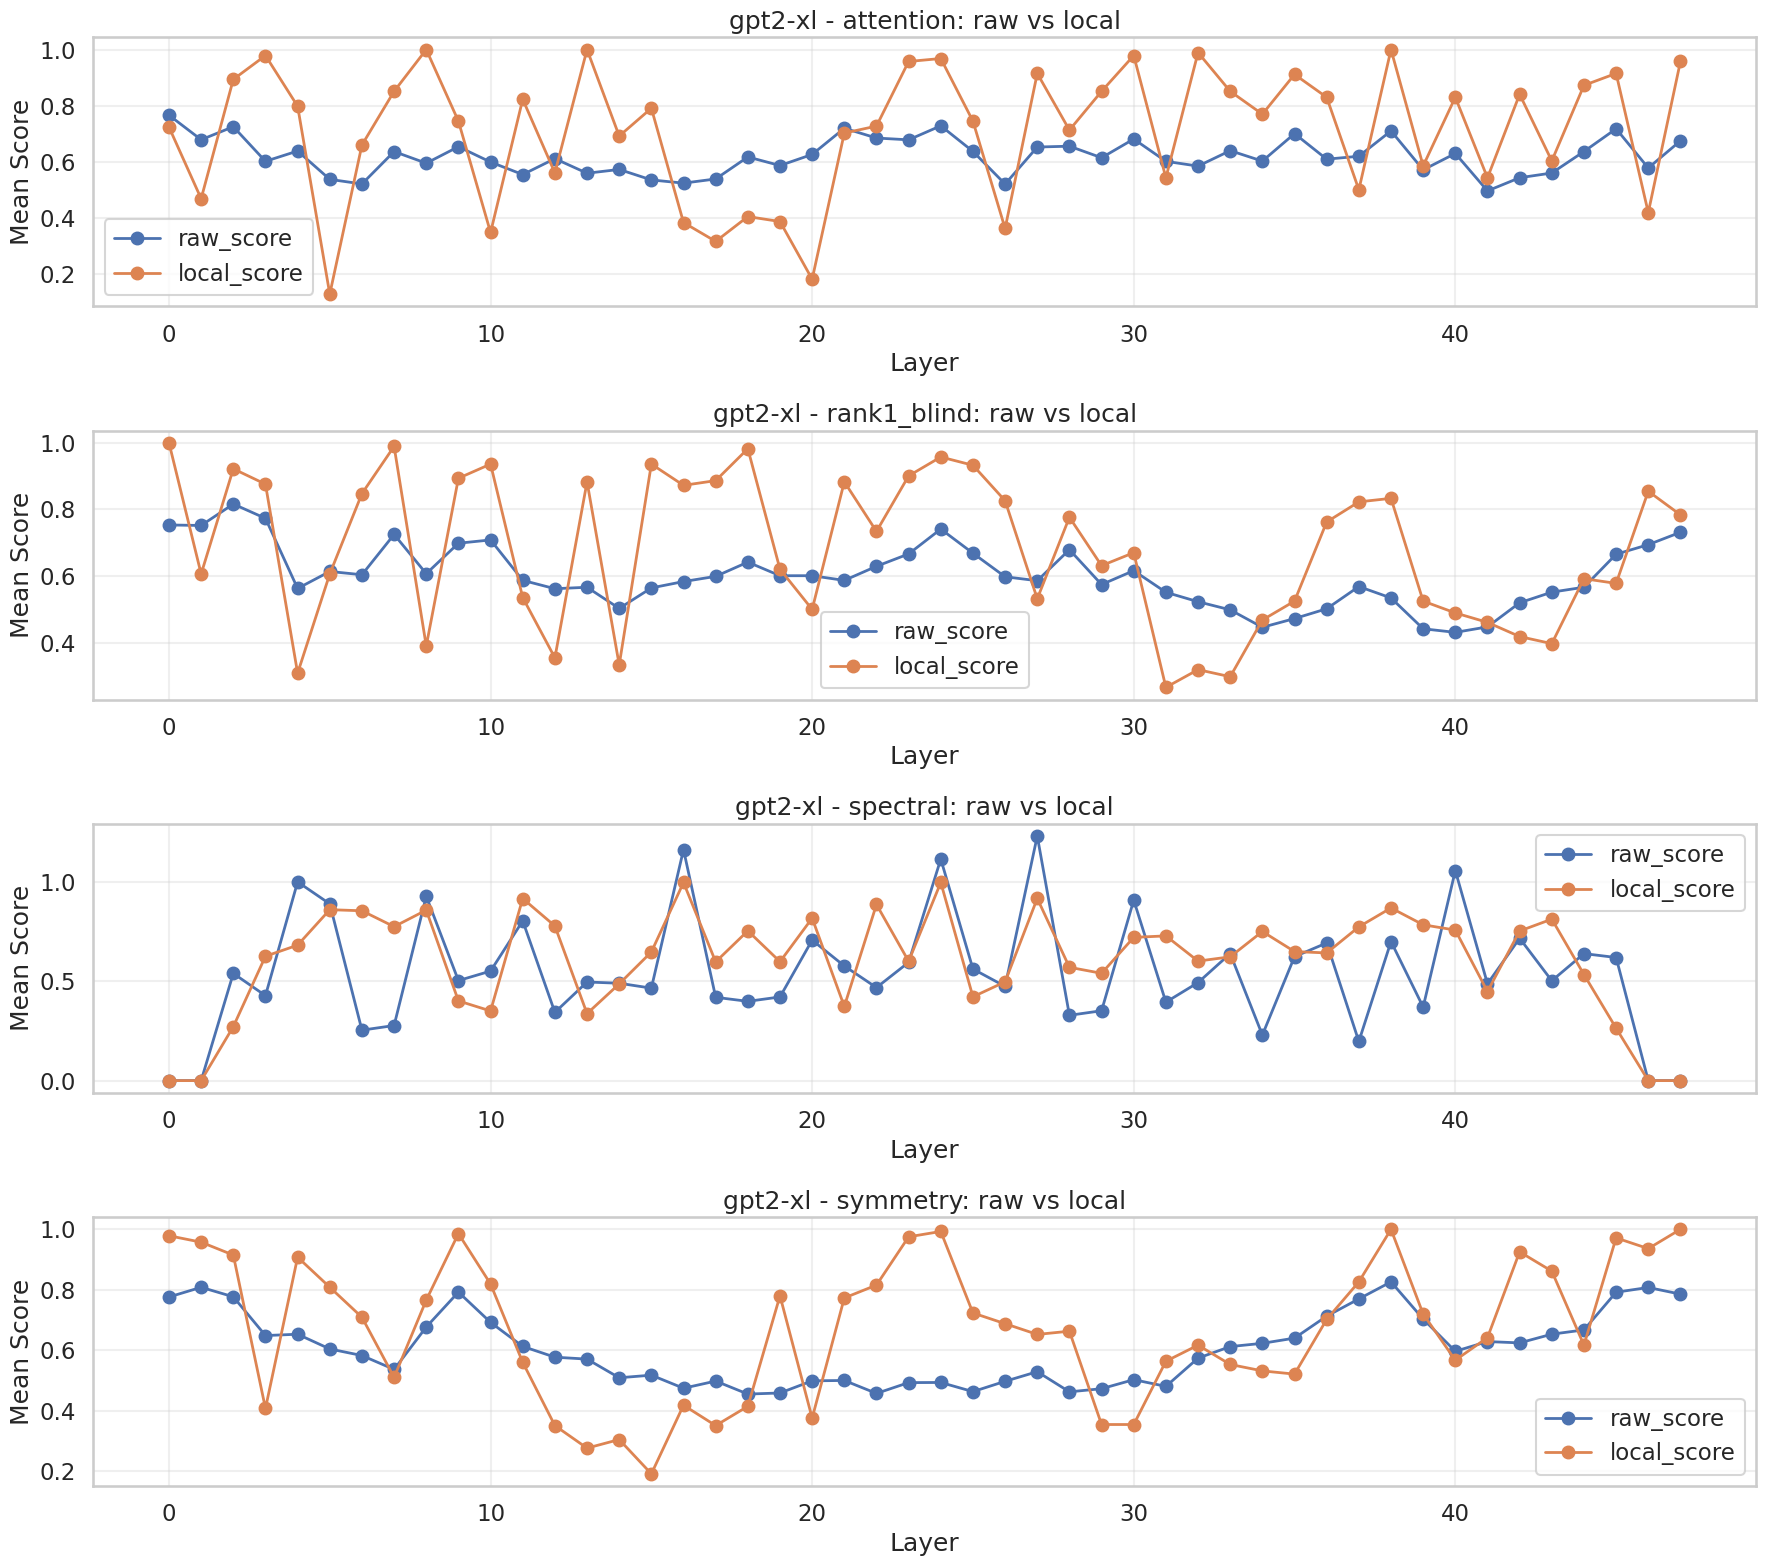

In [5]:
if not local_df.empty:
    agg = (local_df
           .groupby(['model', 'family', 'layer'])[['raw_score', 'local_score']]
           .mean()
           .reset_index())

    for model in sorted(agg['model'].unique()):
        sub_model = agg[agg['model'] == model]
        families = sorted(sub_model['family'].unique())
        fig, axes = plt.subplots(len(families), 1, figsize=(18, 4 * len(families)), sharex=False)
        if len(families) == 1:
            axes = [axes]

        for ax, family in zip(axes, families):
            sub = sub_model[sub_model['family'] == family]
            ax.plot(sub['layer'], sub['raw_score'], marker='o', linewidth=2, label='raw_score')
            ax.plot(sub['layer'], sub['local_score'], marker='o', linewidth=2, label='local_score')
            ax.set_title(f'{model} - {family}: raw vs local')
            ax.set_xlabel('Layer')
            ax.set_ylabel('Mean Score')
            ax.legend(loc='best')

        plt.tight_layout()
        plt.show()

In [6]:
if not local_df.empty:
    corr_rows = []
    for (model, family, case_id), grp in local_df.groupby(['model', 'family', 'case_id']):
        if grp['raw_score'].isna().all() or grp['local_score'].isna().all():
            continue
        corr_rows.append({
            'model': model,
            'family': family,
            'case_id': case_id,
            'raw_local_corr': grp[['raw_score', 'local_score']].corr().iloc[0, 1],
        })

    corr_df = pd.DataFrame(corr_rows)
    display(corr_df.groupby(['model', 'family'])['raw_local_corr'].agg(['count', 'mean', 'std']).reset_index())

,model,family,count,mean,std
0,Qwen/Qwen3-4B,attention,3,0.566744,0.002078
1,Qwen/Qwen3-4B,rank1_blind,3,0.620312,0.003135
2,Qwen/Qwen3-4B,spectral,3,0.674702,0.002912
3,Qwen/Qwen3-4B,symmetry,3,0.432999,0.002079
4,gpt2-large,attention,3,0.335259,0.000916
5,gpt2-large,rank1_blind,3,0.537066,0.006708
6,gpt2-large,spectral,3,0.643292,0.003641
7,gpt2-large,symmetry,3,0.697310,0.005764
8,gpt2-xl,attention,3,0.449066,0.002657
9,gpt2-xl,rank1_blind,3,0.613927,0.005104
